#### `KMeans Clustering on Customers Annual Income and Spending Score`

`Importing Libraries`

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()

import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')


`Loading Dataset`

In [26]:
customers = pd.read_csv('../dataset/mall_customers.csv')
customers.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [27]:
# Shape and info of the data
print(customers.shape)
print(customers.info())

(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [28]:
# Summary Statsistics
customers.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


`Handling Missing Values`

In [29]:
customers.isnull().sum().sort_values(ascending=False)

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

`Handling Duplicates`

In [30]:
customers.duplicated().sum()

np.int64(0)

`Handling Outliers`

In [31]:
q1 = customers.select_dtypes(include=['number']).quantile(0.25)
q3 = customers.select_dtypes(include=['number']).quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound =  q3 + 1.5 * iqr

print(f'\n ==== LOWER BOUND ==== \n {lower_bound}')
print(f'\n ==== UPPER BOUND ==== \n {upper_bound}')


 ==== LOWER BOUND ==== 
 CustomerID               -98.500
Age                       -1.625
Annual Income (k$)       -13.250
Spending Score (1-100)   -22.625
dtype: float64

 ==== UPPER BOUND ==== 
 CustomerID                299.500
Age                        79.375
Annual Income (k$)        132.750
Spending Score (1-100)    130.375
dtype: float64


In [32]:
for cols in customers.select_dtypes(include=['number']).columns:
    mask = (customers[cols] < lower_bound[cols]) | (customers[cols] > upper_bound[cols])
    count = mask.sum()
    if count > 0:
        print(f'{cols}: {count} outliers | '
              f'bounds=[{lower_bound[cols]:.2f}, {upper_bound[cols]:.2f}] | '
              f'actual_min={lower_bound[cols].min():.2f}, actual_max={upper_bound[cols].min():.2f}')

Annual Income (k$): 2 outliers | bounds=[-13.25, 132.75] | actual_min=-13.25, actual_max=132.75


`Data Visualization`

In [33]:
plt.figure(figsize=(22, 10))

figure = px.box(
    customers.select_dtypes(include=['number']),
    orientation='h',
    title = 'Outlier Visualization'
)
figure.show()
plt.show()

<Figure size 2200x1000 with 0 Axes>

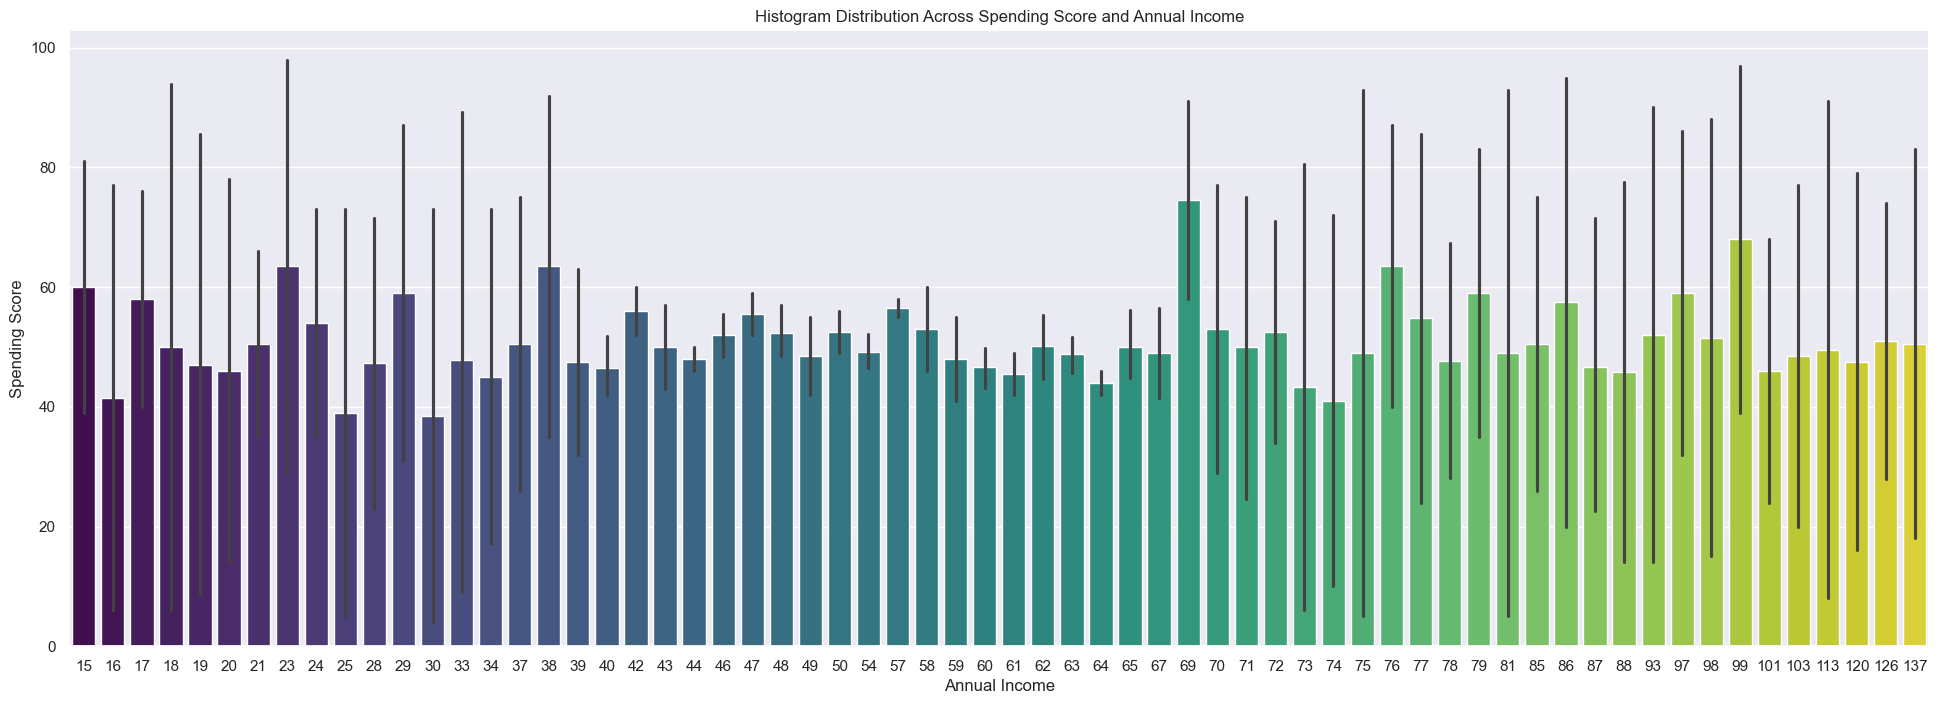

In [34]:
plt.figure(figsize=(24, 8))

sns.barplot(customers,
            x = 'Annual Income (k$)',
            y = 'Spending Score (1-100)',
            palette='viridis'
            )

plt.title('Histogram Distribution Across Spending Score and Annual Income')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()

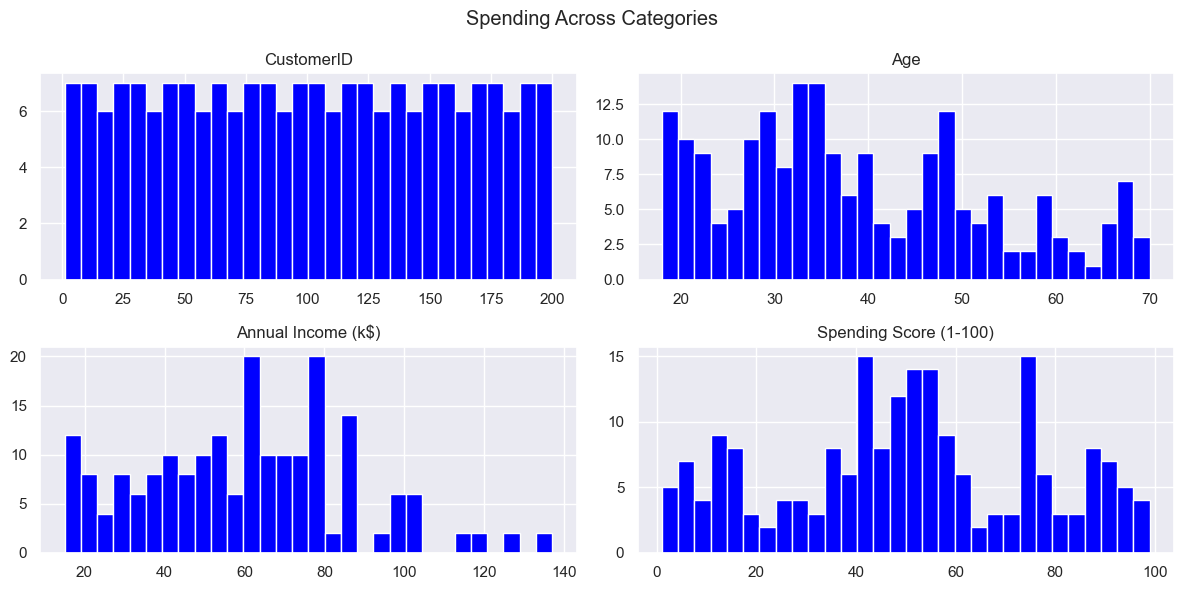

In [35]:
customers.hist(bins=30, figsize=(12, 6), color='blue', edgecolor='white')
plt.suptitle('Spending Across Categories')
plt.tight_layout()
plt.show()

`Dropping CustomerID, Gender, Age Columns`

In [36]:
customers = customers.drop(columns=['CustomerID', 'Gender', 'Age'])

`Feature Scaling`

In [37]:
scaler = StandardScaler()

customers[['Annual Income_T', 'Spending Score_T']] = scaler.fit_transform(customers[['Annual Income (k$)', 'Spending Score (1-100)']])
customers.head()


,Annual Income (k$),Spending Score (1-100),Annual Income_T,Spending Score_T
0,15,39,-1.738999,-0.434801
1,15,81,-1.738999,1.195704
2,16,6,-1.700830,-1.715913
3,16,77,-1.700830,1.040418
4,17,40,-1.662660,-0.395980


`Finding Optimal Number of Clusters`

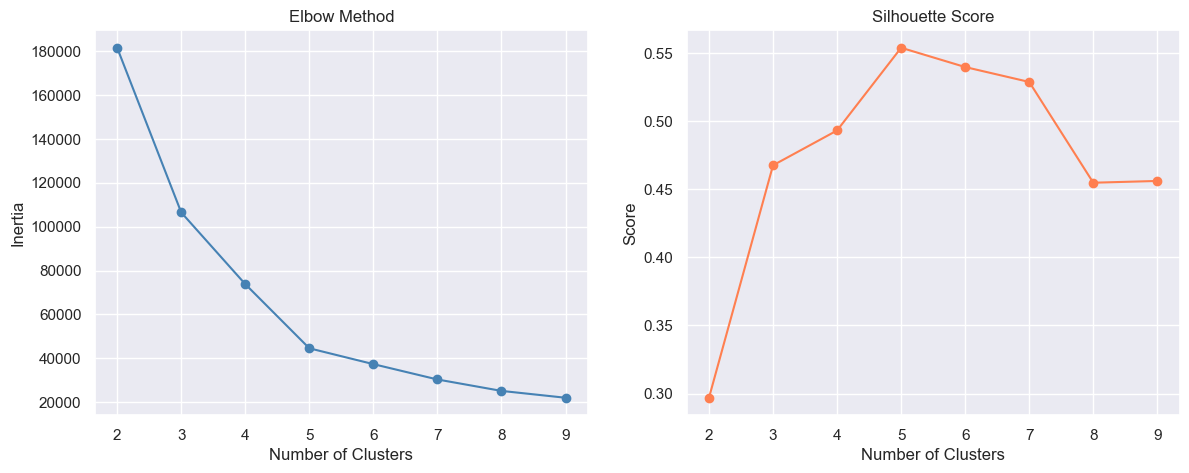

In [38]:
inertia = []
sil_score = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(customers)
    inertia.append(km.inertia_)
    sil_score.append(silhouette_score(customers, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertia, marker='o', color='steelblue')
ax1.set_title('Elbow Method')
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('Inertia')

ax2.plot(k_range, sil_score, marker='o', color='coral')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Number of Clusters')
ax2.set_ylabel('Score')

plt.tight_layout
plt.show()


`Fitting K-KMeans`

In [39]:
'''
km = KMeans(n_clusters=5, random_state=42, n_init=10)
customers['cluster_5'] = km.fit_predict(customers[['Annual Income_T', 'Spending Score_T']])

print(customers['cluster_5'].value_counts())'''

"\nkm = KMeans(n_clusters=5, random_state=42, n_init=10)\ncustomers['cluster_5'] = km.fit_predict(customers[['Annual Income_T', 'Spending Score_T']])\n\nprint(customers['cluster_5'].value_counts())"

In [40]:
customers.head()

,Annual Income (k$),Spending Score (1-100),Annual Income_T,Spending Score_T
0,15,39,-1.738999,-0.434801
1,15,81,-1.738999,1.195704
2,16,6,-1.700830,-1.715913
3,16,77,-1.700830,1.040418
4,17,40,-1.662660,-0.395980


In [41]:
'''plt.scatter(x=customers['Annual Income (k$)'], y=customers['Spending Score (1-100)'], c=customers['cluster_5'])
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()'''

"plt.scatter(x=customers['Annual Income (k$)'], y=customers['Spending Score (1-100)'], c=customers['cluster_5'])\nplt.xlabel('Annual Income')\nplt.ylabel('Spending Score')\nplt.show()"

`Multiple Clusters`

In [42]:
for k in range (1, 6):
    km = KMeans(n_clusters=k)
    km.fit(customers[['Annual Income_T', 'Spending Score_T']])
    customers[f'kmean_{k}'] = km.labels_

customers.head()

,Annual Income (k$),Spending Score (1-100),Annual Income_T,Spending Score_T,kmean_1,kmean_2,kmean_3,kmean_4,kmean_5
0,15,39,-1.738999,-0.434801,0,0,0,0,4
1,15,81,-1.738999,1.195704,0,1,0,0,2
2,16,6,-1.700830,-1.715913,0,0,0,0,4
3,16,77,-1.700830,1.040418,0,1,0,0,2
4,17,40,-1.662660,-0.395980,0,0,0,0,4


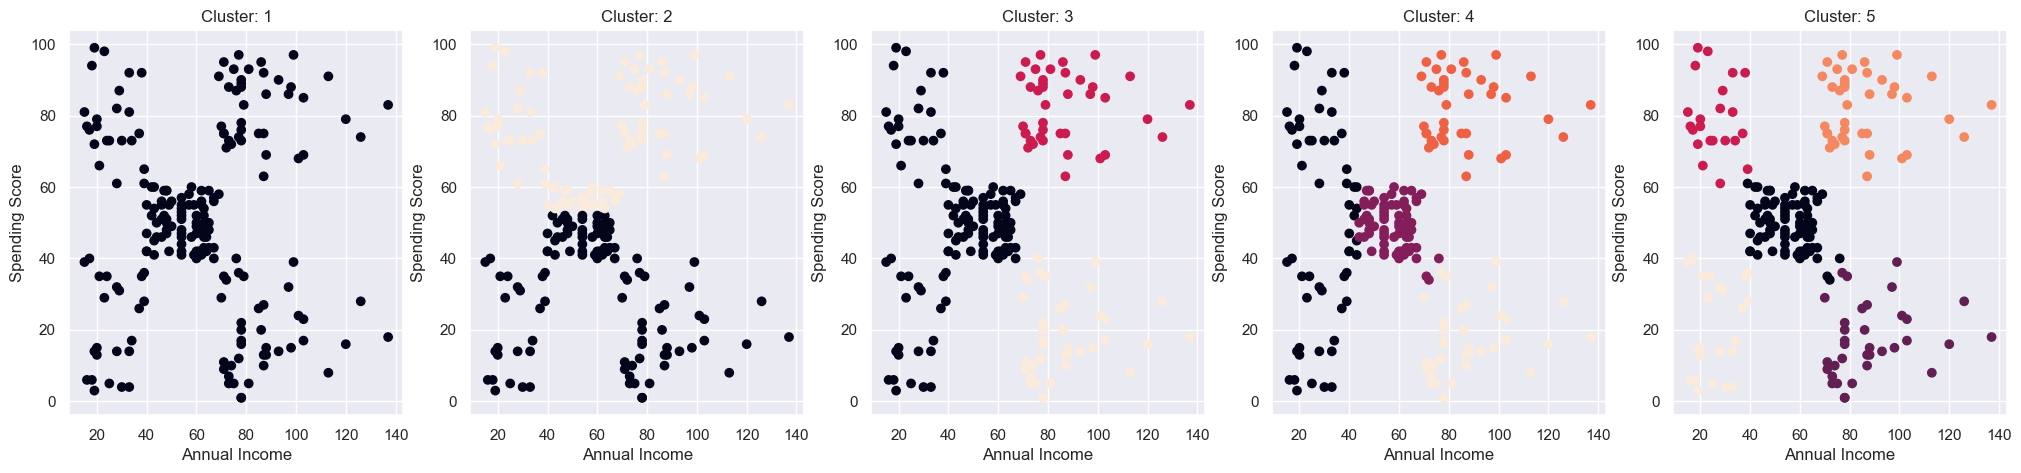

In [43]:
fig, axs = plt.subplots(1, 5, figsize=(25, 5))

for i, ax in enumerate(fig.axes, start=1):
    ax.scatter(x=customers['Annual Income (k$)'], y=customers['Spending Score (1-100)'], c=customers[f'kmean_{i}'])
    ax.set_xlabel('Annual Income')
    ax.set_ylabel('Spending Score')
    ax.set_title(f'Cluster: {i}')

`Profiling and Understanding each Clusters`

In [44]:
profile = ['Annual Income (k$)', 'Spending Score (1-100)']
profile = customers.groupby(['kmean_5'])[profile].mean().round(0)

print(profile)

         Annual Income (k$)  Spending Score (1-100)
kmean_5                                            
0                      55.0                    50.0
1                      88.0                    17.0
2                      26.0                    79.0
3                      87.0                    82.0
4                      26.0                    21.0


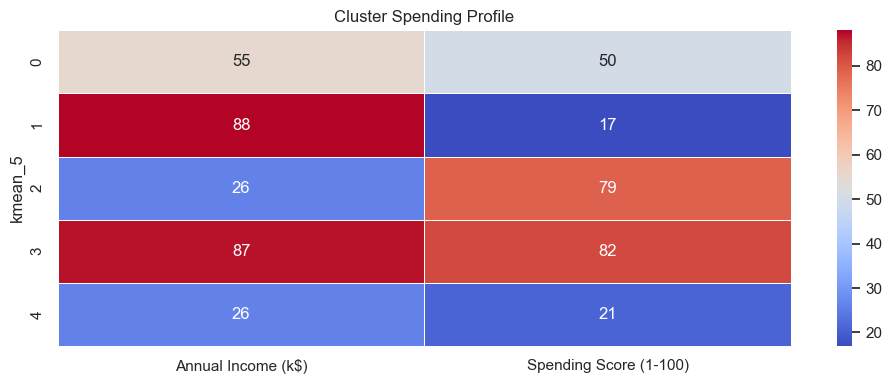

In [45]:
plt.figure(figsize=(10, 4))
sns.heatmap(profile, annot=True, fmt='g', cmap='coolwarm', linewidths=0.5)
plt.title('Cluster Spending Profile')
plt.tight_layout()
plt.show()